<a href="https://colab.research.google.com/github/Shrayash-hub/Machine_Learning/blob/main/BasicFlowOfMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/placement.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [8]:
df.shape

(100, 3)

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df = df.iloc[:,1:] # as we can see first clm is unneccessary so remove it

# df.iloc: Integer-location based indexing used to select data by row/column position.
# [:,: The colon before the comma means "select all rows".
# 1:]: The 1: slice means "start from column index 1 (the second column) to the end of the columns

In [5]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
# lets do Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'], df['iq']) generates a scatter plot using Matplotlib to visualize the relationship between a student's CGPA (x-axis) and IQ (y-axis) from a DataFrame df. It is commonly used to find correlations between two continuous variables, such as identifying if higher CGPA correlates with higher IQ

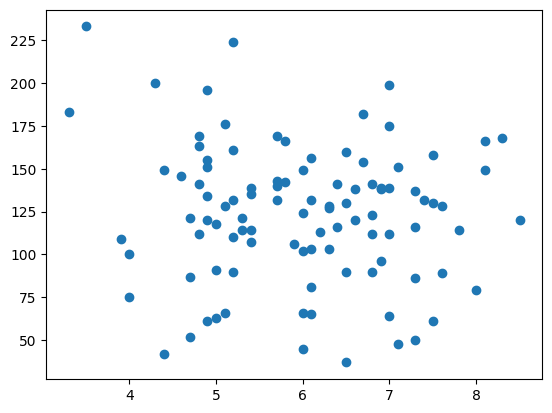

In [10]:
plt.scatter(df['cgpa'],df['iq'])

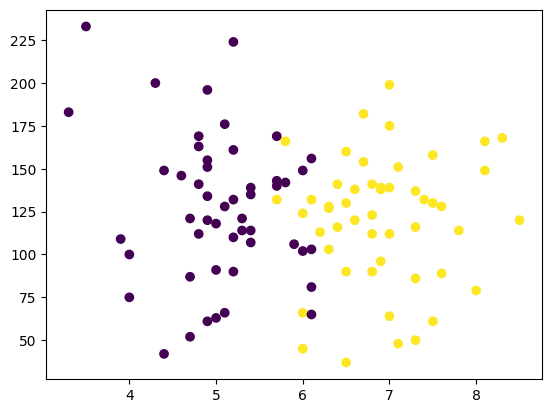

In [12]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])
# using third parameter color , to categories student with placements
# and students without placements

In [16]:
# Now we need to extract input clm (independent variables) and
# output clm (dependent variables)

x = df.iloc[:,0:2] # all rows but starting 2 clms (input)
y = df.iloc[:,-1] # all rows but last clm only (output)


In [40]:
# Now we need to split our dataset in train and test
from sklearn.model_selection import train_test_split

# x, y: The feature matrix () and target vector () to be split.
# test_size=0.1: This argument indicates that 10% of the dataset will be assigned to the test set, while the remaining 90% will be used for training.
# Output: The function returns four values: x_train, x_test, y_train, y_test

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

scaler.fit_transform (X_train): This calculates the mean and standard deviation from the training data and then applies the scaling transformation to it.

scaler.transform(X_test): This applies the exact same mean and standard deviation (learned from the training data) to the test data.

In [41]:
# we need to scale this data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [42]:
# Now we are going to train the model -> logistic regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression() # This line creates an instance (an object) of the LogisticRegression class.



clf.fit(X_train, y_train): This line trains the model using your training dataset.

X_train: The independent variables (features) the model uses to learn patterns.

y_train: The dependent variable (target/labels) that the model tries to predict.

The fit() method calculates the optimal weights () for the sigmoid function to minimize prediction error.

In [43]:
clf.fit(X_train,y_train)

LogisticRegression()

In [44]:
y_pred = clf.predict(X_test) # .predict(): This is a Scikit-learn method that takes new, unseen
# input data and returns the predicted labels or values based on what the model learned during training

accuracy_score(y_test, y_pred) is a function in the scikit-learn library (sklearn.metrics) used to evaluate the performance of classification models. It calculates the proportion of correctly predicted labels (subset accuracy) by comparing the true labels (y_test) to the predicted labels (y_pred).

In [45]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.8

<Axes: >

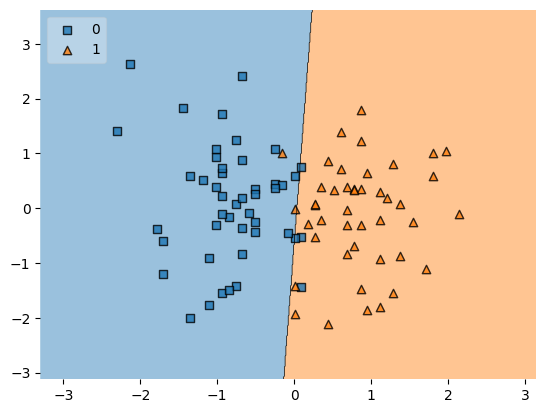

In [46]:
from mlxtend.plotting import plot_decision_regions

# plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)
# is a command from the mlxtend library used to visualize the
# decision boundaries of a machine learning classifier in a 2D or 1D feature space.

plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)
# Using .values converts a Pandas Series to a NumPy array, which is often necessary to avoid compatibility issues with the library's

In [50]:
# converting model into the file

import pickle # Loads the pickle module from the Python Standard Library,
# which handles the conversion of Python objects into byte streams.

pickle.dump(clf,open('model.pkl','wb'))
# open('model.pkl', 'wb'): Creates or opens a file named model.pkl in
# write-binary (wb) mode. This is necessary because pickled data is stored as bytes, not plain text.